### `imports`

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

### `load tensors`

In [2]:
# load tensors
X_tr = torch.load('../Dataset/FD001/X_train.pt')
y_tr = torch.load('../Dataset/FD001/y_train.pt')
X_val = torch.load('../Dataset/FD001/X_val.pt')
y_val = torch.load('../Dataset/FD001/y_val.pt')
X_test = torch.load('../Dataset/FD001/X_test.pt')
y_test = torch.load('../Dataset/FD001/y_test.pt')

In [3]:
print(X_tr.shape)
print(X_val.shape)
print(X_test.shape)

torch.Size([15104, 30, 13])
torch.Size([2627, 30, 13])
torch.Size([100, 30, 13])


### `convert tensor to numpy`

In [4]:
X_tr_np = X_tr.numpy()
X_val_np = X_val.numpy()
X_test_np = X_test.numpy()

y_tr_np = y_tr.numpy()
y_val_np = y_val.numpy()
y_test_np = y_test.numpy()

### `Feature Extraction`

In [5]:
def sequence_to_features(X):
    """
    X shape: (samples, window_size, n_features)
    returns: (samples, engineered_features)
    """

    mean_features = X.mean(axis=1)
    std_features = X.std(axis=1)
    min_features = X.min(axis=1)
    max_features = X.max(axis=1)
    last_features = X[:, -1, :]

    # slope for each sensor
    time = np.arange(X.shape[1])
    slopes = []

    for sample in X:
        sample_slopes = []
        for sensor_idx in range(sample.shape[1]):
            slope = np.polyfit(time, sample[:, sensor_idx], 1)[0]
            sample_slopes.append(slope)
        slopes.append(sample_slopes)

    slope_features = np.array(slopes)

    return np.concatenate([
        mean_features,
        std_features,
        min_features,
        max_features,
        last_features,
        slope_features
    ], axis=1)

In [6]:
X_tr_xgb = sequence_to_features(X_tr_np)
X_val_xgb = sequence_to_features(X_val_np)
X_test_xgb = sequence_to_features(X_test_np)

print(X_tr_xgb.shape)
print(X_val_xgb.shape)
print(X_test_xgb.shape)

(15104, 78)
(2627, 78)
(100, 78)


## **XGBoost Modeling**

- XGBoost cannot directly understand sequences, so we convert each 30-cycle window into tabular features.

In [7]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr_xgb,
    y_tr_np,
    eval_set=[(X_val_xgb, y_val_np)],
    verbose=50
)

[0]	validation_0-rmse:40.80727
[50]	validation_0-rmse:17.11183
[100]	validation_0-rmse:13.08724
[150]	validation_0-rmse:12.49805
[200]	validation_0-rmse:12.42127
[250]	validation_0-rmse:12.38479
[300]	validation_0-rmse:12.42002
[350]	validation_0-rmse:12.48645
[400]	validation_0-rmse:12.53863
[450]	validation_0-rmse:12.56865
[499]	validation_0-rmse:12.59134


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [8]:
y_pred_xgb = xgb_model.predict(X_test_xgb)

mse_xgb = mean_squared_error(y_test_np, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test_np, y_pred_xgb)

print("XGBoost Test MSE:", mse_xgb)
print("XGBoost Test RMSE:", rmse_xgb)
print("XGBoost Test MAE:", mae_xgb)

XGBoost Test MSE: 147.44015502929688
XGBoost Test RMSE: 12.142493773080425
XGBoost Test MAE: 8.952539443969727


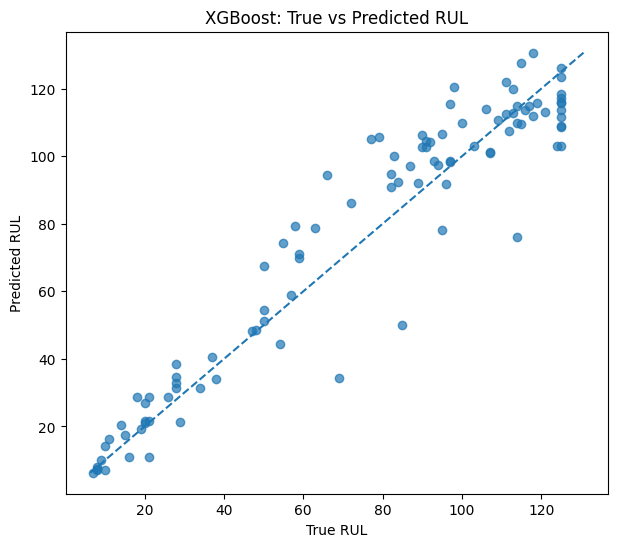

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_np, y_pred_xgb, alpha=0.7)

min_val = min(y_test_np.min(), y_pred_xgb.min())
max_val = max(y_test_np.max(), y_pred_xgb.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: True vs Predicted RUL")
plt.show()

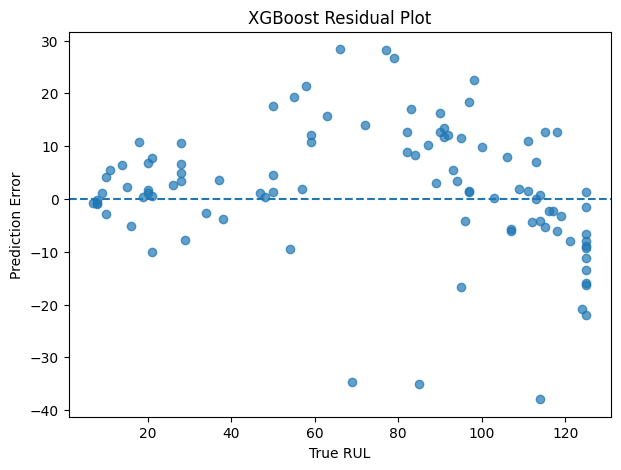

In [10]:
residuals = y_pred_xgb - y_test_np

plt.figure(figsize=(7, 5))
plt.scatter(y_test_np, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')

plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("XGBoost Residual Plot")
plt.show()

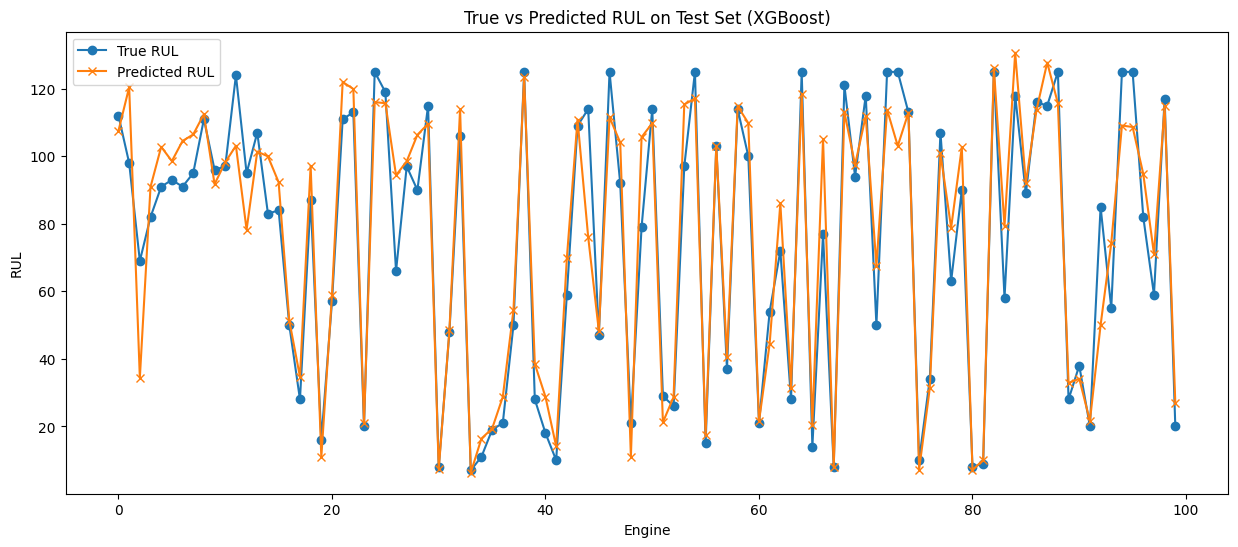

In [14]:
plt.figure(figsize=(15, 6))  
plt.plot(y_test_np, label='True RUL', marker='o')
plt.plot(y_pred_xgb, label='Predicted RUL', marker='x')
plt.title('True vs Predicted RUL on Test Set (XGBoost)')
plt.xlabel('Engine')
plt.ylabel('RUL')
plt.legend()
plt.show()

In [12]:
# number of engines the model got right and wrong (within 15 cycles error)
correct = np.sum(np.abs(y_pred_xgb - y_test_np) <= 15)
print(f"Engines with prediction error <= 15 cycles: {correct}/{len(y_test_np)}")

Engines with prediction error <= 15 cycles: 81/100


### **pipleine**
1. tensor to numpy
2. feature extraction function
3. xgboost model

In [13]:
SAVE_DIR = "../Dataset/FD001"

joblib.dump(xgb_model, f"{SAVE_DIR}/xgb_model.pkl")
print("XGBoost model saved as xgb_model.pkl")

XGBoost model saved as xgb_model.pkl


`Important note`

XGBoost perform very well, close to or even better than LSTM on FD001, because FD001 is relatively simple.

- LSTM captures temporal dependencies directly, while XGBoost uses engineered statistical degradation features extracted from sliding windows.